In [ ]:
# PROJECT PATHS AND GOOGLE DRIVE SETUP


from google.colab import drive
import os
import shutil

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/CSCI370"

DATA_PATH = os.path.join(
    PROJECT_DIR,
    "youtube_comments_BERTtopics.csv"
)

DRIVE_CHROMA_PATH = os.path.join(
    PROJECT_DIR,
    "chroma_youtube_rag"
)

LOCAL_CHROMA_PATH = "/content/chroma_youtube_rag"

print("Project folder exists:", os.path.exists(PROJECT_DIR))
print("Dataset exists:", os.path.exists(DATA_PATH))
print("Chroma folder exists:", os.path.exists(DRIVE_CHROMA_PATH))

Mounted at /content/drive
Project folder exists: True
Dataset exists: True
Chroma folder exists: True


In [ ]:
!pip install sentence-transformers chromadb pandas tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentelem

In [ ]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(24590, 15)


,author,updated_at,like_count,text,video_id,public,clean_text,tokens,lemmas,processed_text,vader_sentiment,vader_score,roberta_sentiment,roberta_score,topic
0,@doomkid1331,2026-05-23T23:42:49Z,0,"Wore my Mk4s until they broke, and exchanged t...",XbXXKhfvSF0,True,wore my mk4s until they broke and exchanged th...,"['wore', 'my', 'mk4s', 'until', 'they', 'broke...","['wear', 'mk4s', 'break', 'exchange', 'mk5', '...",wear mk4s break exchange mk5 perfect mk6,Positive,0.1548,positive,0.455222,348
1,@TurkeyTomDeezNuts,2026-05-23T16:48:27Z,0,These have such bad reviews,XbXXKhfvSF0,True,these have such bad reviews,"['these', 'have', 'such', 'bad', 'reviews']","['bad', 'review']",bad review,Negative,-0.5423,negative,0.926344,26
2,@elevate5136,2026-05-22T04:30:00Z,0,I bought these in South Africa for my 12 hour ...,XbXXKhfvSF0,True,i bought these in south africa for my 12 hour ...,"['i', 'bought', 'these', 'in', 'south', 'afric...","['buy', 'south', 'africa', '12', 'hour', 'flig...",buy south africa 12 hour flight home absolutel...,Positive,0.6012,positive,0.949329,-1
3,@Tdizzle_91,2026-05-21T20:57:05Z,0,Can you compare these to the new collextion mo...,XbXXKhfvSF0,True,can you compare these to the new collextion mo...,"['can', 'you', 'compare', 'these', 'to', 'the'...","['compare', 'new', 'collextion', 'model', 'kno...",compare new collextion model know buy lol,Positive,0.4215,neutral,0.837075,-1
4,@andrewbarf,2026-05-21T09:35:58Z,0,Excellent review Marques; all the main points ...,XbXXKhfvSF0,True,excellent review marques all the main points c...,"['excellent', 'review', 'marques', 'all', 'the...","['excellent', 'review', 'marque', 'main', 'poi...",excellent review marque main point cover waffl...,Positive,0.7085,positive,0.958464,17


In [ ]:
df = df.dropna(subset=["clean_text"]).copy()
df["clean_text"] = df["clean_text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]
df = df.reset_index(drop=True)

texts = df["clean_text"].tolist()

print("Total comments for RAG:", len(texts))

Total comments for RAG: 24590


Create metadata for every comment, including video_id, RoBERTa sentiment,
topic ID, and like count. Metadata supports filtering and makes the
retrieved evidence more interpretable.

In [ ]:
metadatas = []

for i, row in df.iterrows():
    metadatas.append({
        "video_id": str(row.get("video_id", "")),
        "sentiment": str(row.get("roberta_sentiment", "")).strip().lower(),
        "topic": str(row.get("topic", "")),
        "like_count": int(row.get("like_count", 0))
    })

In [ ]:
#LOAD THE SENTENCE-TRANSFORMER EMBEDDING MODEL then

Load all-MiniLM-L6-v2 to represent comments and user queries as
semantic vectors. This allows comments with similar meaning to be
retrieved even when they use different wording.

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# LOAD SAVED CHROMA DATABASE LOCALLY
# ==========================================

import chromadb

if os.path.exists(LOCAL_CHROMA_PATH):
    shutil.rmtree(LOCAL_CHROMA_PATH)

shutil.copytree(
    DRIVE_CHROMA_PATH,
    LOCAL_CHROMA_PATH
)

client = chromadb.PersistentClient(
    path=LOCAL_CHROMA_PATH
)

collection = client.get_collection(
    name="youtube_comments_rag"
)

print("Loaded comments:", collection.count())

Loaded comments: 24590


In [ ]:
def retrieve_comments(query, top_k=30):
    query_embedding = embedding_model.encode([query]).tolist()

    return collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

In [ ]:
#encodes a user query using all-MiniLM-L6-v2 andsearches ChromaDB for semantically similar comment documents.
#It returns retrieved documents, their metadata, and vector distances.

In [ ]:
results = retrieve_comments(
    "What do users think about Sony XM6 headphones?",
    top_k=10
)

for i, comment in enumerate(results["documents"][0], start=1):
    print(f"{i}. {comment}\n")

1. good time to buy sony xm6 than apple headphone

2. sony makes best headphones

3. i love sony when it comes to headphones

4. i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts

5. the only downside of sony headphones is that their headphone cushions are not detachable otherwise they are one of the best headphones on the market

6. i have the xm6 and actually hate the sony connect app its confusing compared to the samsung wearable app that i use with my samsung buds 3 pros btw sony

In [ ]:
results = retrieve_comments(
    "What do users say about Google Pixel phones?",
    top_k=10
)

for i, comment in enumerate(results["documents"][0], start=1):
    print(f"{i}. {comment}\n")

1. still i would say the google pixel to be most userfriendly phone of all the small unnoticable features are like salt in our food it goes unnoticed until you get another phone although i miss the snapdragon pixel still ages like a fine wine its handy true to eye photos no gimmick gestures haptics shortcuts software top of the line

2. google pixel is most definitely not the grandmas choice most pixels sold to the older market get returned and replaced with a samsung its too simple and iphone like which most older customers dont want from their phone

3. i am your big fan however how come you guys are so scared to talk about such a cheap quality mobile phones sold by google i have pixel 7a and battery got swollen after 2 years and 4 months google refused to do anything about it came to know it is such a common problem i dare you guys to make a video on it and expose crap companies like google

4. i do not trust the pixel a series every year they turn out to have a higher rate of failu

In [ ]:
def filter_product_results(results, product_term, final_k=12):
    documents = results["documents"][0]
    metadatas = results["metadatas"][0]
    distances = results["distances"][0]

    product_term = product_term.lower().strip()

    filtered_items = []

    for document, metadata, distance in zip(
        documents,
        metadatas,
        distances
    ):
        if product_term in document.lower():
            filtered_items.append({
                "document": document,
                "metadata": metadata,
                "distance": distance
            })

    return filtered_items[:final_k]

keeps retrieved comments that explicitly mention
the requested product term, such as xm6, pixel, garmin, or iphone.
This reduces unrelated semantic matches.

In [ ]:
results = retrieve_comments(
    "What do users think about Sony XM6 headphones?",
    top_k=30
)

xm6_items = filter_product_results(
    results,
    product_term="xm6",
    final_k=12
)

for i, item in enumerate(xm6_items, start=1):
    print(f"{i}. {item['document']}\n")

1. good time to buy sony xm6 than apple headphone

2. i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts

3. i have the xm6 and actually hate the sony connect app its confusing compared to the samsung wearable app that i use with my samsung buds 3 pros btw sony has always been obsessed with bass remember their mega bass switches on their cd and cassette players i really hated it im not a bass fan i got these xm6 on a promo for 180us for people who sells these for a living and would ne

In [ ]:
results = retrieve_comments(
    "What do users say about Google Pixel phones?",
    top_k=30
)

pixel_items = filter_product_results(
    results,
    product_term="pixel",
    final_k=12
)

for i, item in enumerate(pixel_items, start=1):
    print(f"{i}. {item['document']}\n")

1. still i would say the google pixel to be most userfriendly phone of all the small unnoticable features are like salt in our food it goes unnoticed until you get another phone although i miss the snapdragon pixel still ages like a fine wine its handy true to eye photos no gimmick gestures haptics shortcuts software top of the line

2. google pixel is most definitely not the grandmas choice most pixels sold to the older market get returned and replaced with a samsung its too simple and iphone like which most older customers dont want from their phone

3. i am your big fan however how come you guys are so scared to talk about such a cheap quality mobile phones sold by google i have pixel 7a and battery got swollen after 2 years and 4 months google refused to do anything about it came to know it is such a common problem i dare you guys to make a video on it and expose crap companies like google

4. i do not trust the pixel a series every year they turn out to have a higher rate of failu

In [ ]:
def group_by_sentiment(retrieved_items):
    groups = {
        "positive": [],
        "negative": [],
        "neutral": []
    }

    for item in retrieved_items:
        sentiment = item["metadata"].get("sentiment", "").lower().strip()

        if sentiment in groups:
            groups[sentiment].append(item["document"])

    return groups

group_by_sentiment() groups the retrieved comments according to their
stored RoBERTa labels: positive, negative, or neutral.
This is an evidence display feature and does not re-run sentiment analysis

In [ ]:
xm6_groups = group_by_sentiment(xm6_items)

for sentiment, comments in xm6_groups.items():
    print(f"\n{sentiment.upper()} COMMENTS:")

    for comment in comments:
        print("-", comment)


POSITIVE COMMENTS:
- good time to buy sony xm6 than apple headphone
- got the sony xm6 recently and loved them however they arent that much better than my airpods max ended up returning them as i couldnt justify spending 400 for a minor upgrade surprisingly the airpods max are holding up really well years later
- i still rock a pair of xm2s almost daily bought at release in 2017 i replaced the ear pads but they still work flawlessly xm6 might be my next pair of these kick the bucket i guess sony quality and durability is like driving a toyota

NEGATIVE COMMENTS:
- i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quali

In [ ]:
def create_sentiment_sections(groups, max_comments=5):

    section_titles = {
        "positive": "Positive opinions",
        "negative": "Negative opinions",
        "neutral": "Neutral or mixed observations"
    }

    output = []

    for sentiment in ["positive", "negative", "neutral"]:
        output.append(f"\n{section_titles[sentiment]}:")

        comments = groups.get(sentiment, [])[:max_comments]

        if not comments:
            output.append("- No comments retrieved.")
        else:
            for comment in comments:
                output.append(f"- {comment}")

    return "\n".join(output)

In [ ]:
def create_overall_interpretation(groups, product_name):
    positive_count = len(groups.get("positive", []))
    negative_count = len(groups.get("negative", []))
    neutral_count = len(groups.get("neutral", []))

    return (
        f"For {product_name}, the retrieved evidence contains "
        f"{positive_count} comments labelled positive, "
        f"{negative_count} labelled negative, and "
        f"{neutral_count} labelled neutral or mixed by RoBERTa. "
        "The displayed comments should be reviewed alongside these labels, "
        "especially where users compare different products or models."
    )

In [ ]:
sections = create_sentiment_sections(
    xm6_groups,
    max_comments=5
)

print(sections)


Positive opinions:
- good time to buy sony xm6 than apple headphone
- got the sony xm6 recently and loved them however they arent that much better than my airpods max ended up returning them as i couldnt justify spending 400 for a minor upgrade surprisingly the airpods max are holding up really well years later
- i still rock a pair of xm2s almost daily bought at release in 2017 i replaced the ear pads but they still work flawlessly xm6 might be my next pair of these kick the bucket i guess sony quality and durability is like driving a toyota

Negative opinions:
- i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quali

In [ ]:
!pip install -q transformers accelerate sentencepiece

noq we load Qwen2.5-1.5B-Instruct through Hugging Face Transformers.
The model is used only after retrieval so that it receives evidence
comments instead of answering from general model knowledge.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
results = retrieve_comments(
    "What comfort issues do users mention about Sony XM6 headphones?",
    top_k=10
)

print("Retrieved comments:", len(results["documents"][0]))
print("\nFirst result:\n")
print(results["documents"][0][0])

Retrieved comments: 10

First result:

sony xm phones have always been uncomfortable i have had the xm3s the xm5s returned them both after a couple of weeks because they start hurting so bad i always go back for the qc headphones due to the soft eaemuffs and the leaning additional space for the ear inside the muff i really want to like the sonys but ive always been dissappointed


In [ ]:
# ==========================================
# STRUCTURED LLM PROMPT FOR GROUNDED RAG QA
# ==========================================

def build_evidence_context(documents, max_comments=5, max_chars=550):
    evidence_blocks = []

    for index, document in enumerate(documents[:max_comments], start=1):
        cleaned_document = " ".join(str(document).split())
        evidence_blocks.append(
            f"[{index}] {cleaned_document[:max_chars]}"
        )

    return "\n\n".join(evidence_blocks)


def generate_grounded_rag_answer(query, retrieved_documents):
    evidence_context = build_evidence_context(retrieved_documents)

    messages = [
        {
            "role": "system",
            "content": (
                "You are an evidence-grounded assistant for YouTube tech-review comments. "
                "Use only the retrieved comments. Do not invent facts, specifications, "
                "or opinions. Treat comments as user opinions, not objective truth."
            )
        },
        {
            "role": "user",
            "content": f"""
Question:
{query}

Retrieved evidence:
{evidence_context}

Task:
Write one concise 2-3 sentence answer based only on the evidence.

Rules:
- Start with: "In the retrieved sample,"
- Do not say that all users agree.
- Do not use headings.
- Do not use citations.
- Do not add facts outside the retrieved comments.
"""
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(llm_model.device)

    with torch.no_grad():
        generated_ids = llm_model.generate(
            **model_inputs,
            max_new_tokens=140,
            do_sample=False,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id
        )

    new_tokens = generated_ids[0][model_inputs["input_ids"].shape[1]:]

    llm_answer = tokenizer.decode(
        new_tokens,
        skip_special_tokens=True
    ).strip()

    evidence_references = ", ".join(
        f"[{i}]" for i in range(1, min(5, len(retrieved_documents)) + 1)
    )

    structured_answer = f"""Answer:
{llm_answer}

Evidence references:
{evidence_references}

Caution:
This answer reflects only the retrieved comment sample. Some comments may compare the target product with related or older models.
"""

    return structured_answer, evidence_context

"""
#build_evidence_context() numbers and shortens retrieved comments before
they are placed into the LLM prompt.
generate_grounded_rag_answer() instructs Qwen to use only the supplied
evidence, avoid unsupported product facts, and describe results as a
retrieved sample rather than universal consumer opinion. """


In [ ]:
llm_answer, llm_evidence = generate_grounded_rag_answer(
    query="What comfort issues do users mention about Sony XM6 headphones?",
    retrieved_documents=results["documents"][0]
)

print("LLM-GENERATED RAG ANSWER:\n")
print(llm_answer)

LLM-GENERATED RAG ANSWER:

Answer:
In the retrieved sample, users mention several comfort issues with Sony XM6 headphones, including earcup padding being too thin, clamping sensation around the ears, and excessive heat causing discomfort.

Evidence references:
[1], [2], [3], [4], [5]

Caution:
This answer reflects only the retrieved comment sample. Some comments may compare the target product with related or older models.



In [ ]:
#one reusable function so you do not repeat all

In [ ]:
def run_semantic_rag(
    query,
    product_term,
    product_name,
    candidate_k=30,
    final_k=12,
    max_comments=5
):
    results = retrieve_comments(
        query,
        top_k=candidate_k
    )

    filtered_items = filter_product_results(
        results,
        product_term=product_term,
        final_k=final_k
    )

    groups = group_by_sentiment(filtered_items)

    sections = create_sentiment_sections(
        groups,
        max_comments=max_comments
    )

    summary = create_overall_interpretation(
        groups,
        product_name=product_name
    )

    print(sections)
    print("\nOverall interpretation:\n")
    print(summary)

    return groups

In [ ]:
xm6_groups = run_semantic_rag(
    query="What do users think about Sony XM6 headphones?",
    product_term="xm6",
    product_name="Sony XM6 headphones"
)


Positive opinions:
- good time to buy sony xm6 than apple headphone
- got the sony xm6 recently and loved them however they arent that much better than my airpods max ended up returning them as i couldnt justify spending 400 for a minor upgrade surprisingly the airpods max are holding up really well years later
- i still rock a pair of xm2s almost daily bought at release in 2017 i replaced the ear pads but they still work flawlessly xm6 might be my next pair of these kick the bucket i guess sony quality and durability is like driving a toyota

Negative opinions:
- i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quali

In [ ]:
pixel_groups = run_semantic_rag(
    query="What do users say about Google Pixel phones?",
    product_term="pixel",
    product_name="Google Pixel phones"
)


Positive opinions:
- still i would say the google pixel to be most userfriendly phone of all the small unnoticable features are like salt in our food it goes unnoticed until you get another phone although i miss the snapdragon pixel still ages like a fine wine its handy true to eye photos no gimmick gestures haptics shortcuts software top of the line
- another fantastic review cant believe how far phone technology has come in just a year that vivo phone is mindblowing but seriously the google pixel with thick bezzel had really selling
- i love my pixel phone but i am happy to see the awards being given to phone brands that have been doing their best to improve yearly more power arun
- great video pixel phones are always consistently great

Negative opinions:
- google pixel is most definitely not the grandmas choice most pixels sold to the older market get returned and replaced with a samsung its too simple and iphone like which most older customers dont want from their phone
- i am yo


# BM25 LEXICAL RETRIEVAL


BM25 retrieves comments using exact token overlap between the query and
comments. It is useful for exact product names, model numbers, and
specific feature terms.
tokenize_bm25() removes common question words so meaningful product and
feature words receive greater importance during ranking.

In [ ]:
!pip install -q rank-bm25

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np
import re

BM25_STOPWORDS = {
    "what", "do", "does", "did", "you", "your", "users", "user",
    "people", "think", "thought", "about", "say", "says",
    "the", "a", "an", "and", "or", "for", "to", "of", "in",
    "on", "with", "from", "this", "that", "these", "those",
    "is", "are", "was", "were", "be", "been", "being",
    "can", "could", "would", "should", "i", "im", "my",
    "it", "its", "they", "them", "their", "u"
}

def tokenize_bm25(text):
    tokens = re.findall(r"[a-z0-9]+", str(text).lower())

    return [
        token for token in tokens
        if token not in BM25_STOPWORDS and len(token) > 1
    ]

bm25_corpus = [
    tokenize_bm25(text)
    for text in texts
]

bm25 = BM25Okapi(bm25_corpus)

print("BM25 index created for:", len(bm25_corpus), "comments")
print(tokenize_bm25("What do users think about Sony XM6 headphones?"))

BM25 index created for: 24590 comments
['sony', 'xm6', 'headphones']


In [ ]:
def bm25_retrieve(query, top_k=30):
    query_tokens = tokenize_bm25(query)

    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]

    items = []

    for index in top_indices:
        if scores[index] <= 0:
            continue

        items.append({
            "id": f"comment_{index}",
            "document": texts[index],
            "metadata": metadatas[index],
            "bm25_score": float(scores[index])
        })

    return items

In [ ]:
bm25_xm6_items = bm25_retrieve(
    "What do users think about Sony XM6 headphones?",
    top_k=30
)

bm25_xm6_items = [
    item for item in bm25_xm6_items
    if "xm6" in item["document"].lower()
][:12]

for i, item in enumerate(bm25_xm6_items, start=1):
    print(f"{i}. Score: {item['bm25_score']:.2f}")
    print(item["document"])
    print()

1. Score: 13.17
we got sony xm6 headphones before gta 6 anyway im excited

2. Score: 11.55
sony xm6 before gta6

3. Score: 10.98
sony xm6 vs airpod max

4. Score: 10.98
sony xm6 is king cry haters

5. Score: 10.46
big question airpods max or sony xm6

6. Score: 9.99
really dislike the sony xm6 the sound is horrible imo

7. Score: 9.99
should i go from soundcore space one pro to sony xm6

8. Score: 9.97
my sony ult wear broke last week im eyeing these xm6 funny my sister ult headphones broke too stay away from sony ult wear people its garbage im not lying

9. Score: 9.90
sony headphones wasnt the best benchmark in terms of mics but sound oh my god the best in class the question is should i replace my xm4 with xm6

10. Score: 9.56
good time to buy sony xm6 than apple headphone

11. Score: 9.33
mark5s were a fragile mess that had shoddy hinges sony reddit is chock full of broken headphones within a month of buying xm6 need to be better in that regard

12. Score: 8.81
the hinge on my xm5s 

In [ ]:
def semantic_retrieve_ranked(query, top_k=30):
    results = retrieve_comments(query, top_k=top_k)

    items = []

    for rank, (doc_id, document, metadata, distance) in enumerate(
        zip(
            results["ids"][0],
            results["documents"][0],
            results["metadatas"][0],
            results["distances"][0]
        ),
        start=1
    ):
        items.append({
            "id": doc_id,
            "document": document,
            "metadata": metadata,
            "semantic_rank": rank,
            "distance": float(distance)
        })

    return items

In [ ]:
"""semantic_retrieve_ranked() converts ChromaDB results into ranked items.
hybrid_retrieve() combines semantic and BM25 rankings using Reciprocal
Rank Fusion, rather than combining raw scores from different scales.
A document receives a higher final score when it ranks well in one or
both retrieval methods."""

In [ ]:
def hybrid_retrieve(query, candidate_k=30, final_k=30, rrf_k=60):

    semantic_items = semantic_retrieve_ranked(
        query,
        top_k=candidate_k
    )

    bm25_items = bm25_retrieve(
        query,
        top_k=candidate_k
    )

    combined = {}

    # Add semantic rankings
    for rank, item in enumerate(semantic_items, start=1):
        doc_id = item["id"]

        if doc_id not in combined:
            combined[doc_id] = {
                "id": doc_id,
                "document": item["document"],
                "metadata": item["metadata"],
                "semantic_rank": None,
                "bm25_rank": None,
                "rrf_score": 0
            }

        combined[doc_id]["semantic_rank"] = rank
        combined[doc_id]["rrf_score"] += 1 / (rrf_k + rank)

    # Add BM25 rankings
    for rank, item in enumerate(bm25_items, start=1):
        doc_id = item["id"]

        if doc_id not in combined:
            combined[doc_id] = {
                "id": doc_id,
                "document": item["document"],
                "metadata": item["metadata"],
                "semantic_rank": None,
                "bm25_rank": None,
                "rrf_score": 0
            }

        combined[doc_id]["bm25_rank"] = rank
        combined[doc_id]["rrf_score"] += 1 / (rrf_k + rank)

    hybrid_items = sorted(
        combined.values(),
        key=lambda item: item["rrf_score"],
        reverse=True
    )

    return hybrid_items[:final_k]

In [ ]:
#general
def run_hybrid_rag(
    query,
    product_term,
    product_name,
    candidate_k=50,
    final_k=12,
    max_comments=5
):
    hybrid_items = hybrid_retrieve(
        query,
        candidate_k=candidate_k,
        final_k=candidate_k
    )

    product_items = filter_hybrid_results(
        hybrid_items,
        product_term=product_term,
        final_k=candidate_k
    )

    usable_items = filter_usable_hybrid_comments(
        product_items,
        min_words=7
    )[:final_k]

    groups = group_by_sentiment(usable_items)

    sections = create_sentiment_sections(
        groups,
        max_comments=max_comments
    )

    summary = create_overall_interpretation(
        groups,
        product_name=product_name
    )

    print(sections)
    print("\nOverall interpretation:\n")
    print(summary)

    return usable_items, groups, summary

In [ ]:
def filter_hybrid_results(items, product_term, final_k=12):
    product_term = product_term.lower().strip()

    filtered_items = [
        item for item in items
        if product_term in item["document"].lower()
    ]

    return filtered_items[:final_k]

In [ ]:
def filter_usable_hybrid_comments(items, min_words=7):

    question_patterns = [
        r"^(what|why|how|should|would|do|does|can|could|is|are)\b",
        r"\bwould you recommend\b",
        r"\bshould i\b",
        r"\bdo yall think\b",
        r"\bwhat do you think\b"
    ]

    usable_items = []

    for item in items:
        text = item["document"].strip().lower()
        words = re.findall(r"[a-z0-9]+", text)

        # Removes tiny hype snippets
        if len(words) < min_words:
            continue

        # Removes questions rather than opinions
        if any(re.search(pattern, text) for pattern in question_patterns):
            continue

        usable_items.append(item)

    return usable_items

ilter_hybrid_results() applies literal product filtering.
filter_usable_hybrid_comments() removes very short comments and comments
that are only questions, leaving more useful consumer evidence.

In [ ]:
pixel_hybrid_items, pixel_hybrid_groups, pixel_hybrid_summary = run_hybrid_rag(
    query="What do users say about Google Pixel phones?",
    product_term="pixel",
    product_name="Google Pixel phones"
)


Positive opinions:
- google pixel won most improved phone against google pixel
- best ai phone not google pixel seriously
- great video pixel phones are always consistently great
- i think phone of the year should go to google pixel 9 pro
- many of these phones got good hardware matches iphone google and samsung but the big difference comes when you use the phone pixel is reallly good at productivity perfect for workspace and every google suite and the android os works best with pixel as google made them of course these awards only judges the outside of the phone but in a few years time google pixel esp the new 9s destroys the competition

Negative opinions:
- i do not trust the pixel a series every year they turn out to have a higher rate of failure than the flagships my own a phone killed itself i will never trust google phones again
- i was a google pixel fan till i own one and now i have pixel 8 i dont like it googles own apps such as assistant youtube music etc works better on th

In [ ]:
garmin_hybrid_items, garmin_hybrid_groups, garmin_hybrid_summary = run_hybrid_rag(
    query="What do users think about Garmin smartwatches?",
    product_term="garmin",
    product_name="Garmin smartwatches"
)


Positive opinions:
- smartwatches have a long way to go at least apple watch is not pretentious and is more useful than garmin
- watching this wearing my garmin venu x1 after having an apple watch pixel watch and galaxy watch ultra its my favorite smartwatch and the one that has earned the permanent spot on my wrist its sooo comfortable you barely feel it on your wrist and battery life is better than most smartwatches
- ive used the ultra and garmin and have been a garmin user for 20 years i still prefer the garmin in my opinion if youre a serious user garmin or similar watches like it coros etc are the way to go
- i love the garmin i had an apple watch and it was ok but i hate being a servant and charging another device daily i also like seeing everything on the watch easily on the garmin i dont like having another smartwatch on my wrist its unnecessary
- garmin is the way to go always was a higher quality watch for those who need durability function over fashion and brand

Negative 

In [ ]:
# ==========================================
# RETRIEVAL EVALUATION SETUP
# ==========================================

import time
import pandas as pd

def get_semantic_eval_results(query, product_term, candidate_k=50, final_k=5):
    items = semantic_retrieve_ranked(query, top_k=candidate_k)

    items = filter_hybrid_results(
        items,
        product_term=product_term,
        final_k=candidate_k
    )

    items = filter_usable_hybrid_comments(
        items,
        min_words=7
    )

    return items[:final_k]


def get_bm25_eval_results(query, product_term, candidate_k=50, final_k=5):
    items = bm25_retrieve(query, top_k=candidate_k)

    items = filter_hybrid_results(
        items,
        product_term=product_term,
        final_k=candidate_k
    )

    items = filter_usable_hybrid_comments(
        items,
        min_words=7
    )

    return items[:final_k]


def get_hybrid_eval_results(query, product_term, candidate_k=50, final_k=5):
    items = hybrid_retrieve(
        query,
        candidate_k=candidate_k,
        final_k=candidate_k
    )

    items = filter_hybrid_results(
        items,
        product_term=product_term,
        final_k=candidate_k
    )

    items = filter_usable_hybrid_comments(
        items,
        min_words=7
    )

    return items[:final_k]


def show_retrieval_results(method_name, items):
    print(f"\n{'=' * 80}")
    print(f"{method_name.upper()} RESULTS")
    print("=" * 80)

    for rank, item in enumerate(items, start=1):
        print(f"\nRank {rank}")
        print(item["document"])

In [ ]:
query = "What do users think about Sony XM6 headphones?"
product_term = "xm6"

start = time.perf_counter()
semantic_eval = get_semantic_eval_results(query, product_term)
semantic_time = time.perf_counter() - start

start = time.perf_counter()
bm25_eval = get_bm25_eval_results(query, product_term)
bm25_time = time.perf_counter() - start

start = time.perf_counter()
hybrid_eval = get_hybrid_eval_results(query, product_term)
hybrid_time = time.perf_counter() - start

show_retrieval_results("Semantic", semantic_eval)
show_retrieval_results("BM25", bm25_eval)
show_retrieval_results("Hybrid", hybrid_eval)

print("\nLatency:")
print(f"Semantic: {semantic_time:.3f} seconds")
print(f"BM25: {bm25_time:.3f} seconds")
print(f"Hybrid: {hybrid_time:.3f} seconds")


SEMANTIC RESULTS

Rank 1
good time to buy sony xm6 than apple headphone

Rank 2
i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts

Rank 3
i have the xm6 and actually hate the sony connect app its confusing compared to the samsung wearable app that i use with my samsung buds 3 pros btw sony has always been obsessed with bass remember their mega bass switches on their cd and cassette players i really hated it im not a bass fan i got these xm6 on a promo for 180us for people who sells 

In [ ]:
# Manual relevance labels for the XM6 evaluation query
xm6_labels = {
    "semantic": [1, 1, 1, 1, 1],
    "bm25": [1, 0, 1, 0, 1],
    "hybrid": [1, 1, 1, 1, 1]
}

def precision_at_k(labels):
    return sum(labels) / len(labels)

evaluation_rows = []

for method, labels in xm6_labels.items():
    evaluation_rows.append({
        "query": "What do users think about Sony XM6 headphones?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

xm6_evaluation_df = pd.DataFrame(evaluation_rows)

print(xm6_evaluation_df)

                                            query    method  precision_at_5  \
0  What do users think about Sony XM6 headphones?  semantic             1.0   
1  What do users think about Sony XM6 headphones?      bm25             0.6   
2  What do users think about Sony XM6 headphones?    hybrid             1.0   

   relevant_results  total_results  
0                 5              5  
1                 3              5  
2                 5              5  


In [ ]:
query = "What do users say about Google Pixel phones?"
product_term = "pixel"

start = time.perf_counter()
semantic_eval = get_semantic_eval_results(query, product_term)
semantic_time = time.perf_counter() - start

start = time.perf_counter()
bm25_eval = get_bm25_eval_results(query, product_term)
bm25_time = time.perf_counter() - start

start = time.perf_counter()
hybrid_eval = get_hybrid_eval_results(query, product_term)
hybrid_time = time.perf_counter() - start

show_retrieval_results("Semantic", semantic_eval)
show_retrieval_results("BM25", bm25_eval)
show_retrieval_results("Hybrid", hybrid_eval)

print("\nLatency:")
print(f"Semantic: {semantic_time:.3f} seconds")
print(f"BM25: {bm25_time:.3f} seconds")
print(f"Hybrid: {hybrid_time:.3f} seconds")


SEMANTIC RESULTS

Rank 1
still i would say the google pixel to be most userfriendly phone of all the small unnoticable features are like salt in our food it goes unnoticed until you get another phone although i miss the snapdragon pixel still ages like a fine wine its handy true to eye photos no gimmick gestures haptics shortcuts software top of the line

Rank 2
google pixel is most definitely not the grandmas choice most pixels sold to the older market get returned and replaced with a samsung its too simple and iphone like which most older customers dont want from their phone

Rank 3
i am your big fan however how come you guys are so scared to talk about such a cheap quality mobile phones sold by google i have pixel 7a and battery got swollen after 2 years and 4 months google refused to do anything about it came to know it is such a common problem i dare you guys to make a video on it and expose crap companies like google

Rank 4
i do not trust the pixel a series every year they turn

In [ ]:
# Manual relevance labels for the Google Pixel evaluation query
pixel_labels = {
    "semantic": [1, 1, 1, 1, 0],
    "bm25": [1, 1, 1, 1, 1],
    "hybrid": [1, 1, 1, 1, 1]
}

pixel_evaluation_rows = []

for method, labels in pixel_labels.items():
    pixel_evaluation_rows.append({
        "query": "What do users say about Google Pixel phones?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

pixel_evaluation_df = pd.DataFrame(pixel_evaluation_rows)

print(pixel_evaluation_df)

                                          query    method  precision_at_5  \
0  What do users say about Google Pixel phones?  semantic             0.8   
1  What do users say about Google Pixel phones?      bm25             1.0   
2  What do users say about Google Pixel phones?    hybrid             1.0   

   relevant_results  total_results  
0                 4              5  
1                 5              5  
2                 5              5  


In [ ]:
query = "What do users think about Garmin smartwatches?"
product_term = "garmin"

start = time.perf_counter()
semantic_eval = get_semantic_eval_results(query, product_term)
semantic_time = time.perf_counter() - start

start = time.perf_counter()
bm25_eval = get_bm25_eval_results(query, product_term)
bm25_time = time.perf_counter() - start

start = time.perf_counter()
hybrid_eval = get_hybrid_eval_results(query, product_term)
hybrid_time = time.perf_counter() - start

show_retrieval_results("Semantic", semantic_eval)
show_retrieval_results("BM25", bm25_eval)
show_retrieval_results("Hybrid", hybrid_eval)

print("\nLatency:")
print(f"Semantic: {semantic_time:.3f} seconds")
print(f"BM25: {bm25_time:.3f} seconds")
print(f"Hybrid: {hybrid_time:.3f} seconds")


SEMANTIC RESULTS

Rank 1
i love the garmin i had an apple watch and it was ok but i hate being a servant and charging another device daily i also like seeing everything on the watch easily on the garmin i dont like having another smartwatch on my wrist its unnecessary

Rank 2
smartwatches have a long way to go at least apple watch is not pretentious and is more useful than garmin

Rank 3
i purchased a garmin venu 3 and was very disappointed of its quality and the overall usability compared to my apple watch 9 wich i am using for a couple of months now its so crappy sorry but i returned it imiditiatly garmins battery life of course is a nice to have but in my eyes not really worth because of the mentioned bad usability sure everybody have his own primary expectations on a smartwatch mine is not only the batterylife for me the apple watch is still the more overall best smartwatch

Rank 4
i have to disagree depending on where you are these garmins are way expensive than both applesamsung

In [ ]:
garmin_labels = {
    "semantic": [1, 1, 1, 1, 1],
    "bm25": [1, 1, 1, 1, 1],
    "hybrid": [1, 1, 1, 1, 1]
}

In [ ]:
garmin_evaluation_rows = []

for method, labels in garmin_labels.items():
    garmin_evaluation_rows.append({
        "query": "What do users think about Garmin smartwatches?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

garmin_evaluation_df = pd.DataFrame(garmin_evaluation_rows)

print(garmin_evaluation_df)

                                            query    method  precision_at_5  \
0  What do users think about Garmin smartwatches?  semantic             1.0   
1  What do users think about Garmin smartwatches?      bm25             1.0   
2  What do users think about Garmin smartwatches?    hybrid             1.0   

   relevant_results  total_results  
0                 5              5  
1                 5              5  
2                 5              5  


In [ ]:
all_evaluation_df = pd.concat(
    [
        xm6_evaluation_df,
        pixel_evaluation_df,
        garmin_evaluation_df
    ],
    ignore_index=True
)

print(all_evaluation_df)

average_precision = (
    all_evaluation_df
    .groupby("method")["precision_at_5"]
    .mean()
    .reset_index()
    .rename(columns={"precision_at_5": "mean_precision_at_5"})
)

print("\nAverage Precision@5:")
print(average_precision)

                                            query    method  precision_at_5  \
0  What do users think about Sony XM6 headphones?  semantic             1.0   
1  What do users think about Sony XM6 headphones?      bm25             0.6   
2  What do users think about Sony XM6 headphones?    hybrid             1.0   
3    What do users say about Google Pixel phones?  semantic             0.8   
4    What do users say about Google Pixel phones?      bm25             1.0   
5    What do users say about Google Pixel phones?    hybrid             1.0   
6  What do users think about Garmin smartwatches?  semantic             1.0   
7  What do users think about Garmin smartwatches?      bm25             1.0   
8  What do users think about Garmin smartwatches?    hybrid             1.0   

   relevant_results  total_results  
0                 5              5  
1                 3              5  
2                 5              5  
3                 4              5  
4                 5     

In [ ]:
# Combine all completed evaluation results
all_evaluation_df = pd.concat(
    [
        xm6_evaluation_df,
        pixel_evaluation_df,
        garmin_evaluation_df
    ],
    ignore_index=True
)

print("All evaluation results:")
display(all_evaluation_df)

# Average Precision@5 for each retrieval method
average_precision = (
    all_evaluation_df
    .groupby("method", as_index=False)["precision_at_5"]
    .mean()
    .rename(columns={"precision_at_5": "mean_precision_at_5"})
)

print("\nAverage Precision@5:")
display(average_precision)

All evaluation results:


,query,method,precision_at_5,relevant_results,total_results
0,What do users think about Sony XM6 headphones?,semantic,1.0,5,5
1,What do users think about Sony XM6 headphones?,bm25,0.6,3,5
2,What do users think about Sony XM6 headphones?,hybrid,1.0,5,5
3,What do users say about Google Pixel phones?,semantic,0.8,4,5
4,What do users say about Google Pixel phones?,bm25,1.0,5,5
5,What do users say about Google Pixel phones?,hybrid,1.0,5,5
6,What do users think about Garmin smartwatches?,semantic,1.0,5,5
7,What do users think about Garmin smartwatches?,bm25,1.0,5,5
8,What do users think about Garmin smartwatches?,hybrid,1.0,5,5



Average Precision@5:


,method,mean_precision_at_5
0,bm25,0.866667
1,hybrid,1.000000
2,semantic,0.933333


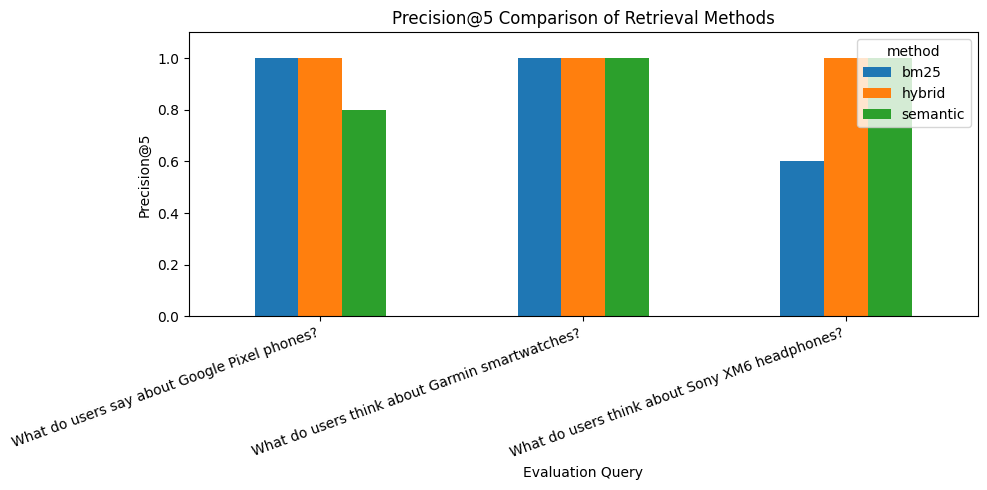

In [ ]:
import matplotlib.pyplot as plt

evaluation_chart = all_evaluation_df.pivot(
    index="query",
    columns="method",
    values="precision_at_5"
)

evaluation_chart.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Precision@5 Comparison of Retrieval Methods")
plt.xlabel("Evaluation Query")
plt.ylabel("Precision@5")
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def compare_retrievers(query, product_term):
    results_by_method = {}
    latencies = {}

    methods = {
        "semantic": get_semantic_eval_results,
        "bm25": get_bm25_eval_results,
        "hybrid": get_hybrid_eval_results
    }

    for method_name, retrieval_function in methods.items():
        start = time.perf_counter()

        results_by_method[method_name] = retrieval_function(
            query,
            product_term
        )

        latencies[method_name] = time.perf_counter() - start

        show_retrieval_results(
            method_name,
            results_by_method[method_name]
        )

    print("\nLatency:")
    for method_name, latency in latencies.items():
        print(f"{method_name.title()}: {latency:.3f} seconds")

    return results_by_method, latencies

In [ ]:
comfort_results, comfort_latencies = compare_retrievers(
    query="What comfort issues do users mention about Sony XM6 headphones?",
    product_term="xm6"
)


SEMANTIC RESULTS

Rank 1
i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts

Rank 2
my xm6s just arrived they are not nearly as comfortable as my xm4s there is a clamping sensation around your ears that is akin to someone cupping their hands and pressing them over your ears the discomfort is the price of noise cancelling which is much much better the sound is better but nothing youll be blown away by the call quality is much much better im considering returning them based on comfort 

In [ ]:
comfort_labels = {
    "semantic": [1, 1, 1, 0, 0],
    "bm25": [0, 0, 0, 0, 0],
    "hybrid": [0, 0, 0, 0, 0]
}

In [ ]:
comfort_evaluation_rows = []

for method, labels in comfort_labels.items():
    comfort_evaluation_rows.append({
        "query": "What comfort issues do users mention about Sony XM6 headphones?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

comfort_evaluation_df = pd.DataFrame(comfort_evaluation_rows)

display(comfort_evaluation_df)

,query,method,precision_at_5,relevant_results,total_results
0,What comfort issues do users mention about Son...,semantic,0.6,3,5
1,What comfort issues do users mention about Son...,bm25,0.0,0,5
2,What comfort issues do users mention about Son...,hybrid,0.0,0,5


In [ ]:
reliability_results, reliability_latencies = compare_retrievers(
    query="What reliability issues do users mention about Google Pixel phones?",
    product_term="pixel"
)


SEMANTIC RESULTS

Rank 1
i do not trust the pixel a series every year they turn out to have a higher rate of failure than the flagships my own a phone killed itself i will never trust google phones again

Rank 2
great video pixel phones are always consistently great

Rank 3
still i would say the google pixel to be most userfriendly phone of all the small unnoticable features are like salt in our food it goes unnoticed until you get another phone although i miss the snapdragon pixel still ages like a fine wine its handy true to eye photos no gimmick gestures haptics shortcuts software top of the line

Rank 4
pixel a series are garbage every year you hear them having battery or overheating problems

Rank 5
google pixel is most definitely not the grandmas choice most pixels sold to the older market get returned and replaced with a samsung its too simple and iphone like which most older customers dont want from their phone

BM25 RESULTS

Rank 1
google phones had ai 5 years ago on my pixel

In [ ]:
reliability_labels = {
    "semantic": [1, 0, 0, 1, 0],
    "bm25": [0, 0, 0, 0, 0],
    "hybrid": [0, 0, 1, 0, 0]
}

In [ ]:
reliability_evaluation_rows = []

for method, labels in reliability_labels.items():
    reliability_evaluation_rows.append({
        "query": "What reliability issues do users mention about Google Pixel phones?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

reliability_evaluation_df = pd.DataFrame(reliability_evaluation_rows)

display(reliability_evaluation_df)

,query,method,precision_at_5,relevant_results,total_results
0,What reliability issues do users mention about...,semantic,0.4,2,5
1,What reliability issues do users mention about...,bm25,0.0,0,5
2,What reliability issues do users mention about...,hybrid,0.2,1,5


In [ ]:
battery_results, battery_latencies = compare_retrievers(
    query="What do users say about Garmin battery life?",
    product_term="garmin"
)


SEMANTIC RESULTS

Rank 1
garmin definitely wins in the battery life department

Rank 2
for me battery life is really high in terms of importance and for that reason alone it has to be garmin i have the epix since jan 22 and i get approx 11 days from the battery with 1hour gps usage daily for my run getting used to this level of battery makes it impossible to go back to apple or samsung which are both arguably more aesthetically pleasing a battery which doesnt last at least a week is crazy in 2024

Rank 3
1 day battery life compared to 2 weeksthis just ends here man garmin day and night literally

Rank 4
my garmin is 250 and has a month battery life idk why he had to compare the most expensive model to the ultra of course it will turn people off

Rank 5
lets be real garmin is superior as a fitness and health tracker with longevity of battery life

BM25 RESULTS

Rank 1
garmin definitely wins in the battery life department

Rank 2
the only thing that garmin has and its better than the ul

In [ ]:
battery_labels = {
    "semantic": [1, 1, 1, 1, 1],
    "bm25": [1, 1, 1, 1, 1],
    "hybrid": [1, 1, 1, 1, 1]
}

In [ ]:
battery_evaluation_rows = []

for method, labels in battery_labels.items():
    battery_evaluation_rows.append({
        "query": "What do users say about Garmin battery life?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

battery_evaluation_df = pd.DataFrame(battery_evaluation_rows)

display(battery_evaluation_df)

,query,method,precision_at_5,relevant_results,total_results
0,What do users say about Garmin battery life?,semantic,1.0,5,5
1,What do users say about Garmin battery life?,bm25,1.0,5,5
2,What do users say about Garmin battery life?,hybrid,1.0,5,5


In [ ]:
fitness_results, fitness_latencies = compare_retrievers(
    query="What do users say about Apple Watch fitness features?",
    product_term="apple watch"
)


SEMANTIC RESULTS

Rank 1
in my experience with apple watch is that ive noticed that the fitness apps lets you pick what you want to see but in my opinion watch is a watch

Rank 2
it is astonishing to me how people choose fitness trackers without caring about their precission at all bad news the apple watch is the best of all i would like not to be the case but it is what it is go to the quantified sciencist and educate yourself

Rank 3
pure fitness with focus on metrics garmin some fitness smart watch functionality apple watch

Rank 4
i hate the sheer number of things on apple watches i know that more features is technically a good thing but id rather use my phone 99999 of the time garmin is much better for the reason i wear a fitness watch to track fitness

Rank 5
i got a garmin forerunner about 4 months ago since i was getting more into running it replaced my apple watch 8 and for the first few weeks i missed all the smart watch features but now i love all the fitness tracking and i

In [ ]:
apple_watch_fitness_labels = {
    "semantic": [1, 1, 1, 0, 0],
    "bm25": [1, 1, 0, 0, 1],
    "hybrid": [1, 1, 0, 0, 0]
}

In [ ]:
apple_watch_fitness_rows = []

for method, labels in apple_watch_fitness_labels.items():
    apple_watch_fitness_rows.append({
        "query": "What do users say about Apple Watch fitness features?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

apple_watch_fitness_evaluation_df = pd.DataFrame(
    apple_watch_fitness_rows
)

display(apple_watch_fitness_evaluation_df)

,query,method,precision_at_5,relevant_results,total_results
0,What do users say about Apple Watch fitness fe...,semantic,0.6,3,5
1,What do users say about Apple Watch fitness fe...,bm25,0.6,3,5
2,What do users say about Apple Watch fitness fe...,hybrid,0.4,2,5


In [ ]:
camera_results, camera_latencies = compare_retrievers(
    query="What do users say about iPhone camera quality?",
    product_term="iphone"
)


SEMANTIC RESULTS

Rank 1
i think this video shot with iphone it have less quality and i know how iphone looks

Rank 2
its so wierd that people buy iphone just to have the best camera but it didnt even won the best camera award well its clearly overhyped

Rank 3
best camera is iphone 17 pro max all these chinese are bad in video but they wont accept it

Rank 4
iphone does not take better photos than google pixel

Rank 5
really expected the iphone to get the camera award at least lol because of their 120 fps 4k and all that but seems not

BM25 RESULTS

Rank 1
i think this video shot with iphone it have less quality and i know how iphone looks

Rank 2
the key new thing on the iphone was the camera button

Rank 3
1223 i thought it would be the iphone 16e because of the 60hz and 1 camera

Rank 4
huawei should have won the best camera coming from a samsung and iphone user

Rank 5
my iphone 16 pro max camera feels worse than my iphone 13 pro max for some reason

HYBRID RESULTS

Rank 1
i thin

In [ ]:
camera_labels = {
    "semantic": [1, 1, 1, 1, 1],
    "bm25": [1, 1, 0, 0, 1],
    "hybrid": [1, 1, 1, 1, 1]
}

In [ ]:
camera_evaluation_rows = []

for method, labels in camera_labels.items():
    camera_evaluation_rows.append({
        "query": "What do users say about iPhone camera quality?",
        "method": method,
        "precision_at_5": precision_at_k(labels),
        "relevant_results": sum(labels),
        "total_results": len(labels)
    })

camera_evaluation_df = pd.DataFrame(camera_evaluation_rows)

display(camera_evaluation_df)

,query,method,precision_at_5,relevant_results,total_results
0,What do users say about iPhone camera quality?,semantic,1.0,5,5
1,What do users say about iPhone camera quality?,bm25,0.6,3,5
2,What do users say about iPhone camera quality?,hybrid,1.0,5,5


In [ ]:
# Combine all 8 evaluation tables
evaluation_tables = [
    xm6_evaluation_df,
    pixel_evaluation_df,
    garmin_evaluation_df,
    comfort_evaluation_df,
    reliability_evaluation_df,
    battery_evaluation_df,
    apple_watch_fitness_evaluation_df,
    camera_evaluation_df
]

all_evaluation_df = pd.concat(
    evaluation_tables,
    ignore_index=True
)

# Make method names cleaner
all_evaluation_df["method"] = all_evaluation_df["method"].str.upper()

# Show every individual evaluation result
print("All retrieval evaluation results:")
display(all_evaluation_df)

All retrieval evaluation results:


,query,method,precision_at_5,relevant_results,total_results
0,What do users think about Sony XM6 headphones?,SEMANTIC,1.0,5,5
1,What do users think about Sony XM6 headphones?,BM25,0.6,3,5
2,What do users think about Sony XM6 headphones?,HYBRID,1.0,5,5
3,What do users say about Google Pixel phones?,SEMANTIC,0.8,4,5
4,What do users say about Google Pixel phones?,BM25,1.0,5,5
5,What do users say about Google Pixel phones?,HYBRID,1.0,5,5
6,What do users think about Garmin smartwatches?,SEMANTIC,1.0,5,5
7,What do users think about Garmin smartwatches?,BM25,1.0,5,5
8,What do users think about Garmin smartwatches?,HYBRID,1.0,5,5
9,What comfort issues do users mention about Son...,SEMANTIC,0.6,3,5


In [ ]:
average_precision_df = (
    all_evaluation_df
    .groupby("method", as_index=False)
    .agg(
        mean_precision_at_5=("precision_at_5", "mean"),
        total_relevant_results=("relevant_results", "sum"),
        total_returned_results=("total_results", "sum")
    )
    .sort_values("mean_precision_at_5", ascending=False)
)

print("Average Precision@5 by retrieval method:")
display(average_precision_df)

Average Precision@5 by retrieval method:


,method,mean_precision_at_5,total_relevant_results,total_returned_results
2,SEMANTIC,0.8,32,40
1,HYBRID,0.7,28,40
0,BM25,0.6,24,40


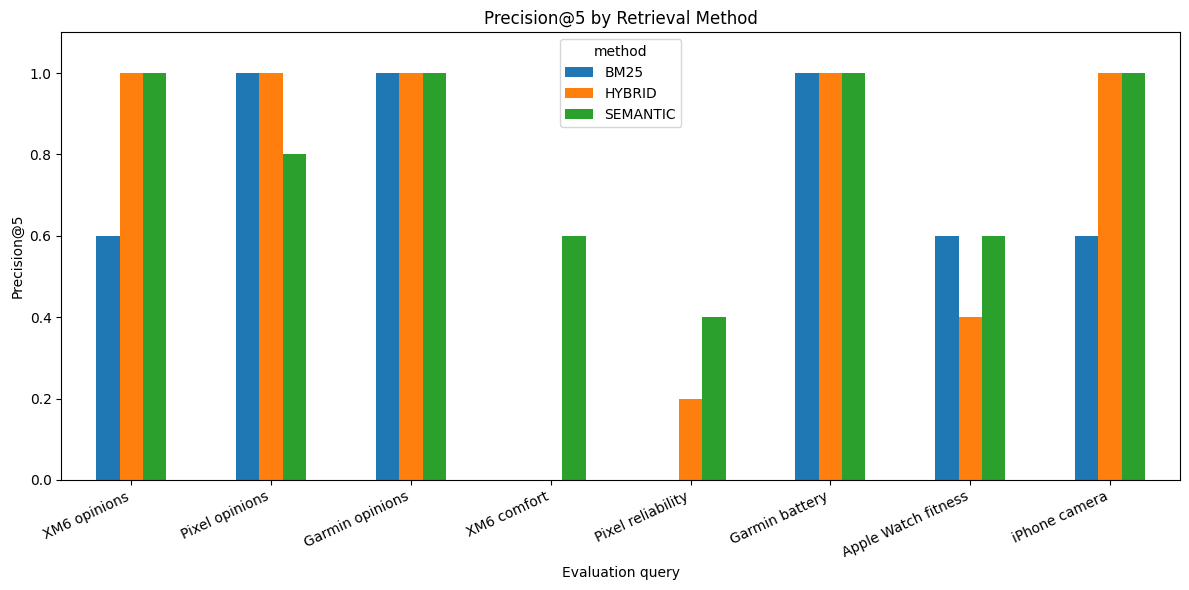

In [ ]:

short_query_names = {
    "What comfort issues do users mention about Sony XM6 headphones?": "XM6 comfort",
    "What do users say about Apple Watch fitness features?": "Apple Watch fitness",
    "What do users say about Garmin battery life?": "Garmin battery",
    "What do users say about Google Pixel phones?": "Pixel opinions",
    "What do users say about iPhone camera quality?": "iPhone camera",
    "What do users think about Garmin smartwatches?": "Garmin opinions",
    "What do users think about Sony XM6 headphones?": "XM6 opinions",
    "What reliability issues do users mention about Google Pixel phones?": "Pixel reliability"
}

chart_df = all_evaluation_df.copy()
chart_df["short_query"] = chart_df["query"].map(short_query_names)

chart_pivot = chart_df.pivot(
    index="short_query",
    columns="method",
    values="precision_at_5"
)

ordered_queries = [
    "XM6 opinions",
    "Pixel opinions",
    "Garmin opinions",
    "XM6 comfort",
    "Pixel reliability",
    "Garmin battery",
    "Apple Watch fitness",
    "iPhone camera"
]

chart_pivot = chart_pivot.reindex(ordered_queries)

chart_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Precision@5 by Retrieval Method")
plt.xlabel("Evaluation query")
plt.ylabel("Precision@5")
plt.ylim(0, 1.1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

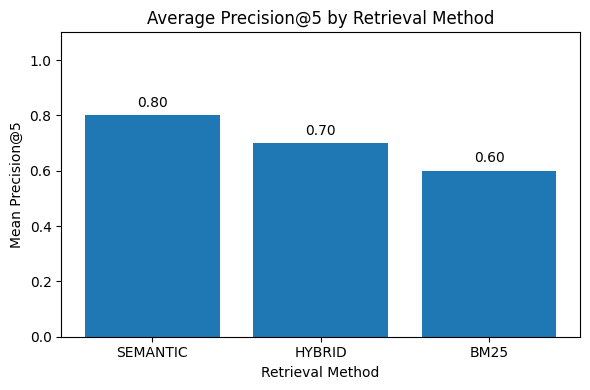

In [ ]:
import matplotlib.pyplot as plt

average_plot = average_precision_df.sort_values(
    "mean_precision_at_5",
    ascending=False
)

plt.figure(figsize=(6, 4))

plt.bar(
    average_plot["method"],
    average_plot["mean_precision_at_5"]
)

plt.title("Average Precision@5 by Retrieval Method")
plt.xlabel("Retrieval Method")
plt.ylabel("Mean Precision@5")
plt.ylim(0, 1.1)

for index, value in enumerate(average_plot["mean_precision_at_5"]):
    plt.text(
        index,
        value + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
#meta filtering

In [ ]:
sample = collection.get(
    ids=["comment_0"],
    include=["documents", "metadatas"]
)

print(sample["documents"][0])
print(sample["metadatas"][0])

wore my mk4s until they broke and exchanged the mk5 for the almost perfect mk6
{'video_id': 'XbXXKhfvSF0', 'topic': '348', 'sentiment': 'positive', 'like_count': 0}


In [ ]:
def retrieve_with_metadata_filter(query, where_filter, top_k=10):
    query_embedding = embedding_model.encode([query]).tolist()

    return collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        where=where_filter,
        include=["documents", "metadatas", "distances"]
    )

In [ ]:
negative_xm6 = retrieve_with_metadata_filter(
    query="What complaints do users have about Sony XM6 headphones?",
    where_filter={"sentiment": "negative"},
    top_k=10
)

for i, (comment, metadata) in enumerate(
    zip(
        negative_xm6["documents"][0],
        negative_xm6["metadatas"][0]
    ),
    start=1
):
    print(f"{i}. {comment}")
    print("Metadata:", metadata)
    print()

1. really dislike the sony xm6 the sound is horrible imo
Metadata: {'video_id': 'SmYuEvjLkQY', 'sentiment': 'negative', 'topic': '-1', 'like_count': 0}

2. marques you can say that its a very bad sounding headphone without any changes from xm5 without bluetooth 6 the higher price is not justified the legendary sony sound is missing this headphone is worse than xm5
Metadata: {'sentiment': 'negative', 'video_id': 'XbXXKhfvSF0', 'like_count': 0, 'topic': '-1'}

3. i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ea

In [ ]:
video_xm6 = retrieve_with_metadata_filter(
    query="What do users think about Sony XM6 headphones?",
    where_filter={"video_id": "XbXXKhfvSF0"},
    top_k=5
)

for i, (comment, metadata) in enumerate(
    zip(video_xm6["documents"][0], video_xm6["metadatas"][0]),
    start=1
):
    print(f"{i}. {comment}")
    print("Metadata:", metadata)
    print()

1. good time to buy sony xm6 than apple headphone
Metadata: {'topic': '38', 'sentiment': 'positive', 'video_id': 'XbXXKhfvSF0', 'like_count': 0}

2. sony makes best headphones
Metadata: {'sentiment': 'positive', 'topic': '129', 'video_id': 'XbXXKhfvSF0', 'like_count': 0}

3. i love sony when it comes to headphones
Metadata: {'like_count': 0, 'sentiment': 'positive', 'video_id': 'XbXXKhfvSF0', 'topic': '129'}

4. the only downside of sony headphones is that their headphone cushions are not detachable otherwise they are one of the best headphones on the market
Metadata: {'topic': '129', 'sentiment': 'positive', 'video_id': 'XbXXKhfvSF0', 'like_count': 0}

5. i have the xm6 and actually hate the sony connect app its confusing compared to the samsung wearable app that i use with my samsung buds 3 pros btw sony has always been obsessed with bass remember their mega bass switches on their cd and cassette players i really hated it im not a bass fan i got these xm6 on a promo for 180us for peo

In [ ]:
#router

In [ ]:
# ==========================================
# QUERY ROUTER
# ==========================================

def route_query(query):
    query = query.lower()

    lookup_terms = [
        "exact model", "specification", "specifications",
        "specs", "model number", "find comments mentioning"
    ]

    comparison_terms = [
        "compare", "comparison", "vs", "versus",
        "better than", "which is better"
    ]

    issue_terms = [
        "issue", "issues", "problem", "problems",
        "comfort", "reliability", "battery",
        "camera", "fitness", "feature", "features",
        "quality", "bug", "bugs", "failure",
        "overheating", "charging", "price"
    ]

    # Check exact keyword/model lookup FIRST
    if any(term in query for term in lookup_terms):
        return "bm25", "Exact keyword or model lookup"

    # Comparisons should use hybrid retrieval
    if any(term in query for term in comparison_terms):
        return "hybrid", "Comparison question"

    # Feature and issue questions use semantic retrieval
    if any(term in query for term in issue_terms):
        return "semantic", "Feature or issue-focused question"

    return "hybrid", "General product-opinion question"

route_query() selects the retrieval method based on query type.
Exact lookup queries use BM25, comparison questions use hybrid retrieval,
issue or feature questions use semantic retrieval, and general opinion
queries default to hybrid retrieval.

In [ ]:
def run_routed_retrieval(query, product_term, top_k=5):
    method, reason = route_query(query)

    print("Selected method:", method.upper())
    print("Reason:", reason)

    if method == "semantic":
        items = get_semantic_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    elif method == "bm25":
        items = get_bm25_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    else:
        items = get_hybrid_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    show_retrieval_results(method, items)

    return method, items

In [ ]:
#run_routed_retrieval() applies the router and prints the selected method,routing reason, and final retrieved evidence comments.


In [ ]:
# ==========================================
# FINAL ROUTED RETRIEVAL ENGINE
# ==========================================

def run_final_engine(
    query,
    product_term,
    product_name,
    candidate_k=50,
    final_k=5
):
    method, reason = route_query(query)

    if method == "semantic":
        items = get_semantic_eval_results(
            query,
            product_term,
            candidate_k=candidate_k,
            final_k=final_k
        )

    elif method == "bm25":
        items = get_bm25_eval_results(
            query,
            product_term,
            candidate_k=candidate_k,
            final_k=final_k
        )

    else:
        items = get_hybrid_eval_results(
            query,
            product_term,
            candidate_k=candidate_k,
            final_k=final_k
        )

    groups = group_by_sentiment(items)

    sections = create_sentiment_sections(
        groups,
        max_comments=final_k
    )

    interpretation = create_overall_interpretation(
        groups,
        product_name=product_name
    )

    print("Selected retrieval method:", method.upper())
    print("Reason:", reason)

    print("\nRetrieved evidence:\n")
    print(sections)

    print("\nOverall interpretation:\n")
    print(interpretation)

    return {
        "method": method,
        "reason": reason,
        "items": items,
        "groups": groups,
        "interpretation": interpretation
    }

run_final_engine() combines routing, retrieval, evidence filtering,
sentiment grouping, and label-faithful interpretation.
This function is evaluated before the final LLM answer layer is added

In [ ]:
method, routed_items = run_routed_retrieval(
    query="What comfort issues do users mention about Sony XM6 headphones?",
    product_term="xm6"
)

Selected method: SEMANTIC
Reason: Feature or issue-focused question

SEMANTIC RESULTS

Rank 1
i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts

Rank 2
my xm6s just arrived they are not nearly as comfortable as my xm4s there is a clamping sensation around your ears that is akin to someone cupping their hands and pressing them over your ears the discomfort is the price of noise cancelling which is much much better the sound is better but nothing youll be blown away by the call quality

In [ ]:
method, garmin_routed_items = run_routed_retrieval(
    query="What do users think about Garmin smartwatches?",
    product_term="garmin"
)

Selected method: HYBRID
Reason: General product-opinion question

HYBRID RESULTS

Rank 1
smartwatches have a long way to go at least apple watch is not pretentious and is more useful than garmin

Rank 2
as a person who constantly changing smartwatches apple watch garmin coros etc this is fair points

Rank 3
watching this wearing my garmin venu x1 after having an apple watch pixel watch and galaxy watch ultra its my favorite smartwatch and the one that has earned the permanent spot on my wrist its sooo comfortable you barely feel it on your wrist and battery life is better than most smartwatches

Rank 4
ive used the ultra and garmin and have been a garmin user for 20 years i still prefer the garmin in my opinion if youre a serious user garmin or similar watches like it coros etc are the way to go

Rank 5
i love the garmin i had an apple watch and it was ok but i hate being a servant and charging another device daily i also like seeing everything on the watch easily on the garmin i dont 

In [ ]:
method, iphone_routed_items = run_routed_retrieval(
    query="Find comments mentioning iPhone 16 Pro Max camera",
    product_term="iphone"
)

Selected method: BM25
Reason: Exact keyword or model lookup

BM25 RESULTS

Rank 1
my iphone 16 pro max camera feels worse than my iphone 13 pro max for some reason

Rank 2
camera comparison galaxy s24ultra vs iphone 16 pro max vs vivo v200 pro vs oppo find x8 pro

Rank 3
brother please do a camera comparison between vivo x200 pro and iphone 16 pro max

Rank 4
wild considering the s22 ultras camera is still better than the iphone 16 pro max

Rank 5
mentioning the iphone 16 in the best camera section should be a loss of channel isnt even top 10


In [ ]:
# ==========================================
# ANSWER-QUALITY EVALUATION
# ==========================================

In [ ]:
final_xm6_result = run_final_engine(
    query="What comfort issues do users mention about Sony XM6 headphones?",
    product_term="xm6",
    product_name="Sony XM6 headphones"
)

Selected retrieval method: SEMANTIC
Reason: Feature or issue-focused question

Retrieved evidence:


Positive opinions:
- No comments retrieved.

Negative opinions:
- i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts
- my xm6s just arrived they are not nearly as comfortable as my xm4s there is a clamping sensation around your ears that is akin to someone cupping their hands and pressing them over your ears the discomfort is the price of noise cancelling which is much much better the 

In [ ]:
final_tests = [
    {
        "query": "What comfort issues do users mention about Sony XM6 headphones?",
        "product_term": "xm6",
        "product_name": "Sony XM6 headphones"
    },
    {
        "query": "What reliability issues do users mention about Google Pixel phones?",
        "product_term": "pixel",
        "product_name": "Google Pixel phones"
    },
    {
        "query": "What do users say about Garmin battery life?",
        "product_term": "garmin",
        "product_name": "Garmin smartwatches"
    },
    {
        "query": "What do users think about Garmin smartwatches?",
        "product_term": "garmin",
        "product_name": "Garmin smartwatches"
    },
    {
        "query": "Find comments mentioning iPhone 16 Pro Max camera",
        "product_term": "iphone",
        "product_name": "iPhone 16 Pro Max"
    }
]

final_results = []

for test in final_tests:
    print("\n" + "=" * 100)
    result = run_final_engine(
        query=test["query"],
        product_term=test["product_term"],
        product_name=test["product_name"]
    )
    final_results.append(result)


Selected retrieval method: SEMANTIC
Reason: Feature or issue-focused question

Retrieved evidence:


Positive opinions:
- No comments retrieved.

Negative opinions:
- i bought the xm6 less than a month ago and honestly i regret it i wouldnt recommend anyone to buy it all those reviews about the xm6 feel like nonsense to me whats the point of great sound if its uncomfortable to wear my ears hurt the earcup padding feels too thin and the clamp is way too tight it makes my ears hot and just overall uncomfortable for me its not an enjoyable experience at all no matter how good the sound quality is if its not comfortable its basically useless sonys biggest mistake here is the shallow padding my ears get pressed and it hurts
- my xm6s just arrived they are not nearly as comfortable as my xm4s there is a clamping sensation around your ears that is akin to someone cupping their hands and pressing them over your ears the discomfort is the price of noise cancelling which is much much better the

In [ ]:
answer_quality_df = pd.DataFrame([
    {
        "query": "XM6 comfort",
        "routing_correct": 1,
        "evidence_relevance_at_5": 0.60,
        "label_faithful_interpretation": 1,
        "notes": "Three direct XM6 comfort comments; two XM5 comparison comments."
    },
    {
        "query": "Pixel reliability",
        "routing_correct": 1,
        "evidence_relevance_at_5": 0.40,
        "label_faithful_interpretation": 1,
        "notes": "Two direct reliability comments; other retrieved comments are broad Pixel opinions."
    },
    {
        "query": "Garmin battery life",
        "routing_correct": 1,
        "evidence_relevance_at_5": 1.00,
        "label_faithful_interpretation": 1,
        "notes": "All retrieved comments discuss Garmin battery life."
    },
    {
        "query": "Garmin opinions",
        "routing_correct": 1,
        "evidence_relevance_at_5": 1.00,
        "label_faithful_interpretation": 1,
        "notes": "Hybrid retrieval returned relevant broad Garmin opinions."
    },
    {
        "query": "iPhone 16 Pro Max camera mentions",
        "routing_correct": 1,
        "evidence_relevance_at_5": 1.00,
        "label_faithful_interpretation": 1,
        "notes": "BM25 returned exact model-and-camera mentions."
    }
])

display(answer_quality_df)

print("Routing accuracy:", answer_quality_df["routing_correct"].mean())
print("Mean evidence relevance:", answer_quality_df["evidence_relevance_at_5"].mean())
print(
    "Label-faithful interpretations:",
    answer_quality_df["label_faithful_interpretation"].mean()
)

,query,routing_correct,evidence_relevance_at_5,label_faithful_interpretation,notes
0,XM6 comfort,1,0.6,1,Three direct XM6 comfort comments; two XM5 com...
1,Pixel reliability,1,0.4,1,Two direct reliability comments; other retriev...
2,Garmin battery life,1,1.0,1,All retrieved comments discuss Garmin battery ...
3,Garmin opinions,1,1.0,1,Hybrid retrieval returned relevant broad Garmi...
4,iPhone 16 Pro Max camera mentions,1,1.0,1,BM25 returned exact model-and-camera mentions.


Routing accuracy: 1.0
Mean evidence relevance: 0.8
Label-faithful interpretations: 1.0


In [ ]:
#mlflow

In [ ]:
#MLflow records retrieval method, parameters, and evaluation metrics.
#alsoo Separate runs are logged for semantic, BM25, hybrid, and the final routed
#engine. The run history is then exported for the Streamlit dashboard

In [ ]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948

In [ ]:
# ==========================================
# MLFLOW EXPERIMENT TRACKING
# ==========================================

import os

# Allow the file-based tracker for this Colab project
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

import mlflow

MLFLOW_PATH = "/content/drive/MyDrive/CSCI370/mlruns"

os.makedirs(MLFLOW_PATH, exist_ok=True)

mlflow.set_tracking_uri(f"file://{MLFLOW_PATH}")
mlflow.set_experiment("YouTube_RAG_Retrieval_Evaluation")

print("MLflow tracking path:", MLFLOW_PATH)

MLflow tracking path: /content/drive/MyDrive/CSCI370/mlruns


In [ ]:
retrieval_csv = "/content/retrieval_evaluation.csv"
answer_quality_csv = "/content/answer_quality_evaluation.csv"

all_evaluation_df.to_csv(retrieval_csv, index=False)
answer_quality_df.to_csv(answer_quality_csv, index=False)

In [ ]:
for _, row in average_precision_df.iterrows():

    method = str(row["method"]).lower()

    with mlflow.start_run(run_name=f"{method}_retrieval"):

        mlflow.log_params({
            "retrieval_method": method,
            "evaluation_queries": int(all_evaluation_df["query"].nunique()),
            "precision_k": 5,
            "embedding_model": "all-MiniLM-L6-v2",
            "bm25_model": "BM25Okapi",
            "hybrid_method": "Reciprocal Rank Fusion"
        })

        mlflow.log_metric(
            "mean_precision_at_5",
            float(row["mean_precision_at_5"])
        )

        mlflow.log_artifact(retrieval_csv)

In [ ]:
with mlflow.start_run(run_name="final_routed_engine"):

    mlflow.log_params({
        "router_type": "rule_based",
        "semantic_model": "all-MiniLM-L6-v2",
        "lexical_model": "BM25Okapi",
        "hybrid_method": "Reciprocal Rank Fusion",
        "candidate_k": 50,
        "final_k": 5
    })

    mlflow.log_metrics({
        "routing_accuracy": float(
            answer_quality_df["routing_correct"].mean()
        ),
        "mean_evidence_relevance": float(
            answer_quality_df["evidence_relevance_at_5"].mean()
        ),
        "label_faithful_interpretation": float(
            answer_quality_df["label_faithful_interpretation"].mean()
        )
    })

    mlflow.log_artifact(answer_quality_csv)

In [ ]:
experiment = mlflow.get_experiment_by_name(
    "YouTube_RAG_Retrieval_Evaluation"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

columns_to_show = [
    column for column in [
        "run_id",
        "tags.mlflow.runName",
        "params.retrieval_method",
        "metrics.mean_precision_at_5",
        "metrics.routing_accuracy",
        "metrics.mean_evidence_relevance",
        "metrics.label_faithful_interpretation"
    ]
    if column in runs.columns
]

display(runs[columns_to_show])

,run_id,tags.mlflow.runName,params.retrieval_method,metrics.mean_precision_at_5,metrics.routing_accuracy,metrics.mean_evidence_relevance,metrics.label_faithful_interpretation
0,5f9f48b1ce14411d9e8965223bbeffda,final_routed_engine,None,NaN,1.0,0.8,1.0
1,ff34cc9fbda24220a01705658e7ef6d3,bm25_retrieval,bm25,0.6,NaN,NaN,NaN
2,3c5fd533b34741988b76ab15c7c814fa,hybrid_retrieval,hybrid,0.7,NaN,NaN,NaN
3,28ec77681cef477ebd2dafa600191755,semantic_retrieval,semantic,0.8,NaN,NaN,NaN
4,dc45280f9af5491dab8eb45cf4969158,final_routed_engine,None,NaN,1.0,0.8,1.0
5,d88c5487bb3648858ef1ea8a7d26d81e,bm25_retrieval,bm25,0.6,NaN,NaN,NaN
6,015bcf83430d48d9a8094e204fc46810,hybrid_retrieval,hybrid,0.7,NaN,NaN,NaN
7,b240b2ebff7d43c1b1e5162136fb69fa,semantic_retrieval,semantic,0.8,NaN,NaN,NaN


In [ ]:
# Export full run history to CSV for the Streamlit dashboard
mlflow_export_path = "/content/drive/MyDrive/CSCI370/mlflow_runs_export.csv"

runs[columns_to_show].to_csv(mlflow_export_path, index=False)

print("Exported MLflow runs to:", mlflow_export_path)
display(runs[columns_to_show])

from google.colab import files
files.download(mlflow_export_path)

Exported MLflow runs to: /content/drive/MyDrive/CSCI370/mlflow_runs_export.csv


,run_id,tags.mlflow.runName,params.retrieval_method,metrics.mean_precision_at_5,metrics.routing_accuracy,metrics.mean_evidence_relevance,metrics.label_faithful_interpretation
0,5f9f48b1ce14411d9e8965223bbeffda,final_routed_engine,None,NaN,1.0,0.8,1.0
1,ff34cc9fbda24220a01705658e7ef6d3,bm25_retrieval,bm25,0.6,NaN,NaN,NaN
2,3c5fd533b34741988b76ab15c7c814fa,hybrid_retrieval,hybrid,0.7,NaN,NaN,NaN
3,28ec77681cef477ebd2dafa600191755,semantic_retrieval,semantic,0.8,NaN,NaN,NaN
4,dc45280f9af5491dab8eb45cf4969158,final_routed_engine,None,NaN,1.0,0.8,1.0
5,d88c5487bb3648858ef1ea8a7d26d81e,bm25_retrieval,bm25,0.6,NaN,NaN,NaN
6,015bcf83430d48d9a8094e204fc46810,hybrid_retrieval,hybrid,0.7,NaN,NaN,NaN
7,b240b2ebff7d43c1b1e5162136fb69fa,semantic_retrieval,semantic,0.8,NaN,NaN,NaN


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

run_routed_llm_rag() is the complete TechView RAG workflow:
user query -> rule-based router -> selected retrieval method ->
filtered evidence comments -> structured Qwen prompt ->
grounded answer with evidence references and caution statement.

In [ ]:
# FULL ROUTED LLM-RAG PIPELINE


def run_routed_llm_rag(query, product_term, top_k=5):
    method, reason = route_query(query)

    if method == "semantic":
        items = get_semantic_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    elif method == "bm25":
        items = get_bm25_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    else:
        items = get_hybrid_eval_results(
            query,
            product_term,
            candidate_k=50,
            final_k=top_k
        )

    retrieved_documents = [
        item["document"]
        for item in items
    ]

    llm_answer, evidence_context = generate_grounded_rag_answer(
        query=query,
        retrieved_documents=retrieved_documents
    )

    print("Selected retrieval method:", method.upper())
    print("Reason:", reason)
    print("\nLLM-GENERATED RAG ANSWER:\n")
    print(llm_answer)

    return {
        "method": method,
        "reason": reason,
        "items": items,
        "llm_answer": llm_answer,
        "evidence_context": evidence_context
    }

In [ ]:
routed_llm_result = run_routed_llm_rag(
    query="What comfort issues do users mention about Sony XM6 headphones?",
    product_term="xm6"
)

Selected retrieval method: SEMANTIC
Reason: Feature or issue-focused question

LLM-GENERATED RAG ANSWER:

Answer:
In the retrieved sample, users mention comfort issues such as earcup padding being too thin, the clamp feeling too tight, causing ear pain and overheating, leading to overall discomfort.

Evidence references:
[1], [2], [3], [4], [5]

Caution:
This answer reflects only the retrieved comment sample. Some comments may compare the target product with related or older models.

